In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [3]:
data = np.load("dataset_mc_ml_v1_prepared.npz")

# USIAMO SOLO IL TRAIN + VAL (più dati, niente leakage)
X = np.vstack([data["X_train"], data["X_val"]])

# (opzionale, solo per interpretazione dopo)
y = np.vstack([data["y_train"], data["y_val"]])


In [4]:
Ks = [2, 3, 4,5,6]
sil_scores = []

for K in Ks:
    kmeans = KMeans(n_clusters=K, random_state=0, n_init=20)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"K={K}, silhouette={score:.3f}")


K=2, silhouette=0.303
K=3, silhouette=0.312
K=4, silhouette=0.321
K=5, silhouette=0.272
K=6, silhouette=0.268


In [5]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=0, n_init=50)
clusters = kmeans.fit_predict(X)


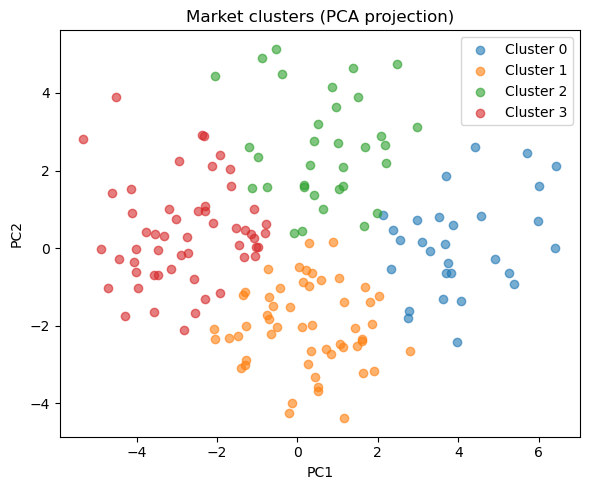

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
for c in range(K):
    plt.scatter(
        X_pca[clusters == c, 0],
        X_pca[clusters == c, 1],
        label=f"Cluster {c}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Market clusters (PCA projection)")
plt.tight_layout()
plt.show()


In [7]:
feature_names = [
    "poa_mean", "poa_std", "poa_amp",
    "Mbar_mean", "Mbar_std", "Mbar_amp",
    "n_mean", "n_std", "n_amp",
    "churn_mean", "churn_std", "churn_amp"
]

for c in range(K):
    print(f"\n=== Cluster {c} ===")
    mean_feat = X[clusters == c].mean(axis=0)
    for name, val in zip(feature_names, mean_feat):
        print(f"{name:12s}: {val:+.3f}")



=== Cluster 0 ===
poa_mean    : -1.527
poa_std     : +1.382
poa_amp     : +1.385
Mbar_mean   : +1.499
Mbar_std    : +1.392
Mbar_amp    : +1.365
n_mean      : -1.043
n_std       : -0.590
n_amp       : -0.599
churn_mean  : -1.229
churn_std   : -0.671
churn_amp   : -0.631

=== Cluster 1 ===
poa_mean    : +0.303
poa_std     : -0.537
poa_amp     : -0.531
Mbar_mean   : +0.007
Mbar_std    : -0.311
Mbar_amp    : -0.320
n_mean      : -0.674
n_std       : -0.785
n_amp       : -0.776
churn_mean  : -0.526
churn_std   : -0.833
churn_amp   : -0.825

=== Cluster 2 ===
poa_mean    : -0.746
poa_std     : +0.962
poa_amp     : +0.962
Mbar_mean   : +0.416
Mbar_std    : +0.648
Mbar_amp    : +0.589
n_mean      : +0.575
n_std       : +0.922
n_amp       : +0.933
churn_mean  : +0.212
churn_std   : +0.939
churn_amp   : +0.972

=== Cluster 3 ===
poa_mean    : +0.957
poa_std     : -0.767
poa_amp     : -0.783
Mbar_mean   : -1.088
Mbar_std    : -0.833
Mbar_amp    : -0.776
n_mean      : +0.860
n_std       : +0.525


In [8]:
theta_cost = y[:, 0]
theta_cong = y[:, 1]

for c in range(K):
    print(f"\nCluster {c}:")
    print("theta_cost mean:", theta_cost[clusters == c].mean())
    print("theta_cong mean:", theta_cong[clusters == c].mean())



Cluster 0:
theta_cost mean: 1.1797740843483342
theta_cong mean: 0.5219401179541004

Cluster 1:
theta_cost mean: 1.2698001476518272
theta_cong mean: 0.5701141241891783

Cluster 2:
theta_cost mean: 1.2199678868157064
theta_cong mean: 0.5542602080486941

Cluster 3:
theta_cost mean: 1.2769616908978771
theta_cong mean: 0.5761931182939839
